# Kernel Estimation

In [1]:
import os
os.chdir("../..")

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from garage.envs.point_env import PointEnv
from src.learning.aa_policy_training.utils import GarageToGymWrapper
from src.learning.bb_symmetry.kernel_approx import KernelFrameEstimator
from src.learning.bb_symmetry.utils import train_neural_kernel

# Oracle kernel: rotational vector field around goal (inlined from oracles.py)
def rotation_vector_field(p_batch, center):
    G = torch.tensor([[0.0, -1.0], [1.0, 0.0]], dtype=torch.float32)
    projected = p_batch - center
    grad = projected @ G.T
    norm = grad.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    return (grad / norm).unsqueeze(1)  # (n, 1, 2)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/Paul_Nitschke/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/Paul_Nitschke/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## 1. Sample trajectories

In [ ]:
np.random.seed(42)
test_tasks = PointEnv().sample_tasks(20, mode="linspace")
test_envs = [PointEnv().set_task(t) for t in test_tasks]

N_EXPLORATION_EPISODES = 50
MAX_STEPS_PER_EPISODE = 100
SIGMA_EXPLORATION_POLICY = 0.1
N_steps_explorations = N_EXPLORATION_EPISODES * MAX_STEPS_PER_EPISODE

def random_policy(sigma=SIGMA_EXPLORATION_POLICY):
    return np.random.normal(loc=0.0, scale=sigma, size=(2,))

def sample_environment(task, policy, max_steps):
    # #region agent log
    import json as _json

    # #endregion
    task_gym = GarageToGymWrapper(task)
    obs = task_gym.reset()
    observations, actions, rewards, next_observations = [], [], [], []
    _done_count = 0
    for _ in range(max_steps):
        observations.append(obs)
        action = policy()
        obs, reward, done, _ = task_gym.step(action)
        if done:
            _done_count += 1
            _res = task_gym.reset()
            obs = _res  # wrapper returns only obs; do not unpack or obs becomes scalar
        actions.append(action)
        rewards.append(reward)
        next_observations.append(obs)
    for idx in [0, 99, 100, 101]:
        o = observations[idx]
    return (
        np.array(observations),
        np.array(actions),
        np.array(rewards),
        np.array(next_observations),
    )

ENV_IDX = 0
states, actions, rewards, s_primes = sample_environment(
    test_envs[ENV_IDX], random_policy, N_steps_explorations
)
print(f"Collected {len(states)} samples.")

Collected 5000 samples.


## 2. Pointwise kernel estimation (relaxed hyperparameters)

In [4]:
data_R = torch.tensor(s_primes, dtype=torch.float32)
rewards_th = torch.tensor(rewards, dtype=torch.float32)

# Relaxed hyperparameters per plan: >50% of samples should get usable kernel estimates
frame_estimator = KernelFrameEstimator(
    states=states,
    actions=actions,
    rewards=rewards_th,
    s_primes=s_primes,
    kernel_dim_R=1,
    data_R=data_R,
    epsilon_ball=0.2,
    epsilon_level_set=0.02,
    n_neighbors_in_level_set=6,
    use_relative_epsilon_level_set=True,
)
kernel_basis_vectors = frame_estimator.compute()

n_with_basis = len(kernel_basis_vectors)
pct = 100 * n_with_basis / len(s_primes)
print(f"Samples with kernel estimates: {n_with_basis} / {len(s_primes)} ({pct:.1f}%)")

/Users/Paul_Nitschke/Library/CloudStorage/OneDrive-McKinsey&Company/Desktop/Projects/geo_meta_rl/geo_meta_rl/src/learning/bb_symmetry/kernel_approx.py:70: UserWarning: TODO: Dimension of kernel should be actively inferred, not passed as an argument.
  warnings.warn("TODO: Dimension of kernel should be actively inferred, not passed as an argument.")
Compute Point-Wise Bases via PCA...: 100%|██████████| 5000/5000 [00:00<00:00, 46197.96it/s]
INFO:root:0 tangent vectors for 1.74% of samples
1 tangent vectors for 2.82% of samples
2 tangent vectors for 3.26% of samples
3 tangent vectors for 2.38% of samples
4 tangent vectors for 2.6% of samples
5 tangent vectors for 2.6% of samples
>=6 tangent vectors for 84.6% of samples. Discarding all other tangent vectors.


Samples with kernel estimates: 4230 / 5000 (84.6%)


In [5]:
idxs = list(kernel_basis_vectors.keys())
pointwise_kernel_frames = torch.stack([kernel_basis_vectors[i] for i in idxs], dim=0)
pointwise_kernel_frames = pointwise_kernel_frames.permute(0, 2, 1)  # (n, kernel_dim, ambient_dim)
s_primes_kernel = torch.tensor(s_primes[idxs], dtype=torch.float32)
goal = test_envs[ENV_IDX]._task["goal"]

## 3. Validate: compare pointwise kernel to oracle

In [6]:
goal_t = torch.tensor(goal, dtype=torch.float32)
oracle_kernel_at_points = rotation_vector_field(s_primes_kernel, center=goal_t)  # (n, 1, 2)

# Cosine similarity (orientation-invariant: use abs); shape (n,)
cos_sim = torch.cosine_similarity(
    pointwise_kernel_frames.view(-1, 2),
    oracle_kernel_at_points.view(-1, 2),
    dim=-1,
)
mean_abs_cos = torch.abs(cos_sim).mean().item()
print(f"Mean |cos(angle)| vs oracle: {mean_abs_cos:.4f} (1.0 = perfect alignment)")

Mean |cos(angle)| vs oracle: 0.9935 (1.0 = perfect alignment)


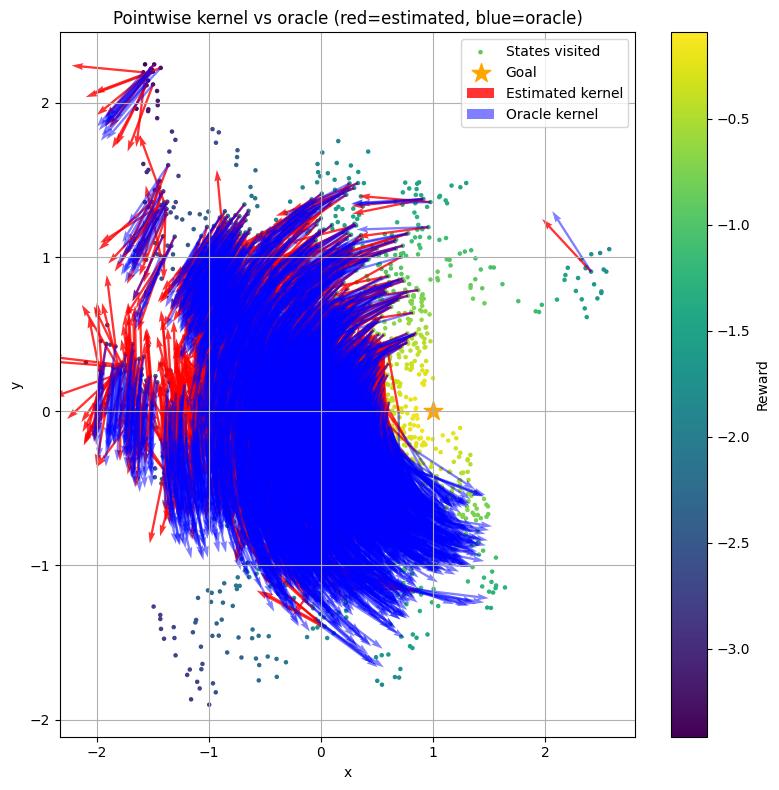

In [7]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(s_primes[:, 0], s_primes[:, 1], c=rewards, s=5, cmap="viridis", label="States visited")
plt.scatter(goal[0], goal[1], marker="*", s=200, c="orange", label="Goal")
scale = 8
plt.quiver(
    s_primes_kernel[:, 0], s_primes_kernel[:, 1],
    pointwise_kernel_frames.squeeze(1)[:, 0], pointwise_kernel_frames.squeeze(1)[:, 1],
    color="red", scale=scale, width=0.004, label="Estimated kernel", alpha=0.8
)
plt.quiver(
    s_primes_kernel[:, 0], s_primes_kernel[:, 1],
    oracle_kernel_at_points.squeeze(1)[:, 0], oracle_kernel_at_points.squeeze(1)[:, 1],
    color="blue", scale=scale, width=0.004, label="Oracle kernel", alpha=0.5
)
plt.legend()
plt.colorbar(sc, label="Reward")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pointwise kernel vs oracle (red=estimated, blue=oracle)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Train neural kernel on improved targets

In [8]:
neural_kernel, kernel_losses = train_neural_kernel(
    data_R=s_primes_kernel,
    kernel_bases=pointwise_kernel_frames,
    lasso_coef=0.15,
    sample_data_how="uniform_manifold",
    temperature=0.75,
    k=20,
    epochs=2_000,
    batch_size=128,
)
final_loss = kernel_losses[-1]
print(f"Final training loss: {final_loss:.4f} (target: -1.0)")
assert np.isclose(final_loss, -1.0, atol=0.15), f"Final loss {final_loss:.4f} not close to -1.0"
print("Check passed: final training loss is close to -1.0")

Train kernel w/ sampling uniform_manifold and β=0.75.:   0%|          | 0/2000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling...
INFO:root:Initialized uniform manifold sampling.
/Users/Paul_Nitschke/Library/CloudStorage/OneDrive-McKinsey&Company/Desktop/Projects/geo_meta_rl/geo_meta_rl/src/learning/bb_symmetry/utils.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(weights)
Training kernel — loss=-0.9789 (should be -1): 100%|██████████| 2000/2000 [00:01<00:00, 1761.66epoch/s]

Final training loss: -0.9789 (target: -1.0)


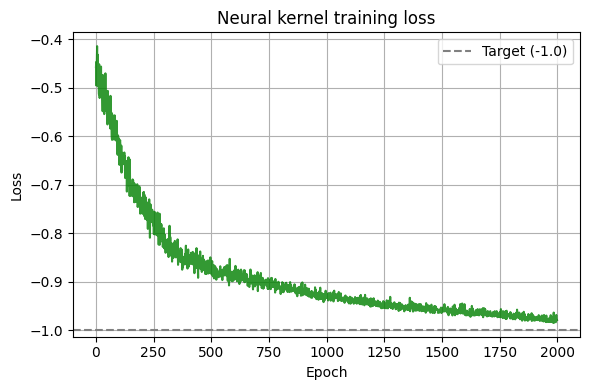

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(kernel_losses, color="green", alpha=0.8)
plt.axhline(y=-1.0, color="gray", linestyle="--", label="Target (-1.0)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural kernel training loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Plot learned kernel field

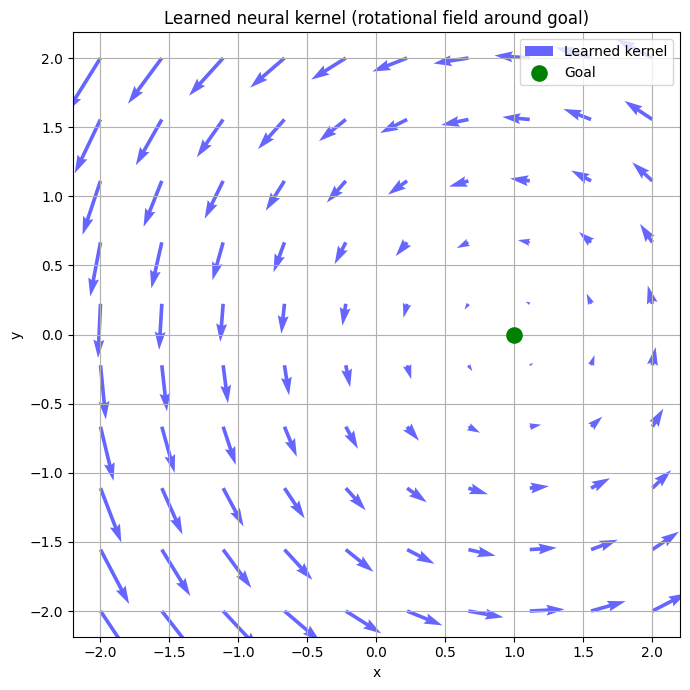

In [10]:
def create_linear_mesh(num_points):
    x = torch.linspace(-2, 2, num_points)
    y = torch.linspace(-2, 2, num_points)
    grid_x, grid_y = torch.meshgrid(x, y, indexing="xy")
    return torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

data_plot = create_linear_mesh(10)
kernel_plot = neural_kernel(data_plot).detach()
plt.figure(figsize=(7, 7))
plt.quiver(
    data_plot[:, 0], data_plot[:, 1],
    kernel_plot[:, :, 0], kernel_plot[:, :, 1],
    color="blue", label="Learned kernel", alpha=0.6
)
plt.scatter(goal[0], goal[1], color="green", s=120, label="Goal", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Learned neural kernel (rotational field around goal)")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

## 6. Compute kernel for all tasks

Sample trajectories and run pointwise kernel estimation for every task; store the kernel results in a list.

In [14]:
# Same hyperparameters as in section 2
import warnings
kernels_all_tasks = []
neural_kernels_all_tasks = []  # trained neural kernel per task (for section 7)
ps_base = None  # points for left-action optimization (base task kernel sample points)
for task_idx in range(len(test_envs)):
    states_t, actions_t, rewards_t, s_primes_t = sample_environment(
        test_envs[task_idx], random_policy, N_steps_explorations
    )
    data_R_t = torch.tensor(s_primes_t, dtype=torch.float32)
    rewards_th_t = torch.tensor(rewards_t, dtype=torch.float32)
    frame_estimator_t = KernelFrameEstimator(
        states=states_t,
        actions=actions_t,
        rewards=rewards_th_t,
        s_primes=s_primes_t,
        kernel_dim_R=1,
        data_R=data_R_t,
        epsilon_ball=0.2,
        epsilon_level_set=0.02,
        n_neighbors_in_level_set=6,
        use_relative_epsilon_level_set=True,
    )
    kernel_basis_vectors_t = frame_estimator_t.compute()
    kernels_all_tasks.append(kernel_basis_vectors_t)
    # Train neural kernel and verify loss for this task (atol=0.1)
    idxs_t = list(kernel_basis_vectors_t.keys())
    pointwise_frames_t = torch.stack([kernel_basis_vectors_t[i] for i in idxs_t], dim=0).permute(0, 2, 1)
    s_primes_kernel_t = torch.tensor(s_primes_t[idxs_t], dtype=torch.float32)
    neural_kernel_t, kernel_losses_t = train_neural_kernel(
        data_R=s_primes_kernel_t,
        kernel_bases=pointwise_frames_t,
        lasso_coef=0.15,
        sample_data_how="uniform_manifold",
        temperature=0.75,
        k=20,
        epochs=2_000,
        batch_size=128,
    )
    final_loss_t = kernel_losses_t[-1]
    if not np.isclose(final_loss_t, -1.0, atol=0.1):
        warnings.warn(f"Task {task_idx}: final training loss {final_loss_t:.4f} did not converge (target -1.0, atol=0.1)")
    neural_kernels_all_tasks.append(neural_kernel_t)
    if task_idx == 0:
        ps_base = s_primes_kernel_t.detach().clone()

print(f"Computed kernels for {len(kernels_all_tasks)} tasks.")

/Users/Paul_Nitschke/Library/CloudStorage/OneDrive-McKinsey&Company/Desktop/Projects/geo_meta_rl/geo_meta_rl/src/learning/bb_symmetry/kernel_approx.py:70: UserWarning: TODO: Dimension of kernel should be actively inferred, not passed as an argument.
  warnings.warn("TODO: Dimension of kernel should be actively inferred, not passed as an argument.")
Compute Point-Wise Bases via PCA...: 100%|██████████| 5000/5000 [00:00<00:00, 49802.94it/s]
INFO:root:0 tangent vectors for 2.3% of samples
1 tangent vectors for 2.86% of samples
2 tangent vectors for 2.34% of samples
3 tangent vectors for 2.74% of samples
4 tangent vectors for 2.54% of samples
5 tangent vectors for 2.28% of samples
>=6 tangent vectors for 84.94% of samples. Discarding all other tangent vectors.
Train kernel w/ sampling uniform_manifold and β=0.75.:   0%|          | 0/2000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling...
INFO:root:Initialized uniform manifold sampling.
/Users/Paul_Nitschke/Library/Cloud

Computed kernels for 20 tasks.


## 7. Infer left actions (base task 0)

Given the base task (index 0), infer for each other task a left action (rotation) that transforms its kernel frame into the base task's kernel. Output: 19 rotation matrices `left_actions_lgs` (one per task 1..19).

In [23]:
from typing import List

class InferLieWeightsLgs:
    """Infers weights for log-left actions that align each task's kernel to the base task kernel."""

    def __init__(self,
                 n_tasks: int,
                 generator_lgs: torch.Tensor,
                 lie_dimension: int,
                 kernel_frame_base_task: torch.nn.Module,
                 kernel_frame_i_tasks: List[torch.nn.Module],
                 encoder_geo: torch.nn.Module,
                 decoder_geo: torch.nn.Module,
                 lasso_coef_lgs: float = 0.01):
        self._n_tasks = n_tasks
        self.generator_lgs = generator_lgs
        self.lie_dimension = lie_dimension
        self.kernel_frame_base_task = kernel_frame_base_task
        self.kernel_frame_i_tasks = kernel_frame_i_tasks
        self._lasso_coef_lgs = lasso_coef_lgs
        self.encoder_geo = encoder_geo
        self.decoder_geo = decoder_geo
        self.task_losses = None
        self.task_losses_reg = None

        self.weights = [torch.randn((lie_dimension,), requires_grad=True) for _ in range(n_tasks)]
        self.optimizers = [torch.optim.Adam([self.weights[i]], lr=0.0045) for i in range(n_tasks)]

    def step_optimization(self,
                          ps: torch.Tensor,
                          encoder_geo: torch.nn.Module,
                          decoder_geo: torch.nn.Module,) -> float:
        """Performs one step of optimization on the weights of the log-left actions."""
        self.log_lgs = [torch.einsum("d,dnm->nm", self.weights[idx_task], self.generator_lgs) for idx_task in range(self._n_tasks - 1)]
        self.lgs = [torch.matrix_exp(self.log_lgs[i]) for i in range(self._n_tasks - 1)]

        loss = self.infer_weights(ps, self.lgs, self.log_lgs, encoder_geo, decoder_geo)
        for optimizer in self.optimizers:
            optimizer.zero_grad()
        loss.backward()
        for optimizer in self.optimizers:
            optimizer.step()
        return loss.item()

    def infer_weights(self,
                      ps: torch.Tensor,
                      lgs: torch.Tensor,
                      log_lgs: torch.Tensor,
                      encoder_geo: torch.nn.Module,
                      decoder_geo: torch.nn.Module,) -> float:
        """Computes kernel alignment loss of all left-actions."""
        def encoded_left_action(lg, ps):
            tilde_ps = encoder_geo(ps)
            lg_tilde_ps = torch.einsum("mn,n->m", lg, tilde_ps)
            return decoder_geo(lg_tilde_ps)

        tilde_ps = encoder_geo(ps)
        lg_tilde_ps = [torch.einsum("mn,bn->bm", lgs[i], tilde_ps) for i in range(self._n_tasks - 1)]
        lg_ps = [decoder_geo(lg_tilde_ps[i]) for i in range(self._n_tasks - 1)]

        frame_ps = self.kernel_frame_base_task(ps)
        frames_i_lg_ps = torch.stack([self.kernel_frame_i_tasks[idx_task](lg_ps[idx_task]) for idx_task in range(self._n_tasks - 1)], dim=0)

        jac_lgs = [torch.vmap(torch.func.jacrev(encoded_left_action, argnums=1), in_dims=(None, 0))(lgs[i], ps) for i in range(self._n_tasks - 1)]
        jac_lgs_frame_ps = [torch.einsum("bmn,bdn->bdm", jac_lgs[i], frame_ps) for i in range(self._n_tasks - 1)]
        self.task_losses = -torch.stack([torch.abs(torch.cosine_similarity(jac_lgs_frame_ps[i], frames_i_lg_ps[i], dim=-1)).mean(-1).mean(-1) for i in range(self._n_tasks - 1)], dim=0)

        self.task_losses_reg = torch.sum(torch.stack([self._lasso_coef_lgs * torch.norm(log_lg, p=1, dim=(-1, -2)).mean(-1) for log_lg in log_lgs]))

        return self.task_losses.mean() + self.task_losses_reg

In [24]:
# Rotation generator (Lie algebra): [[0,-1],[1,0]], shape (1, 2, 2) for lie_dimension=1
ORACLE_GENERATOR_LGS = torch.tensor([[0.0, -1.0], [1.0, 0.0]], dtype=torch.float32).unsqueeze(0)

n_tasks = len(test_envs)
identity = lambda x: x

infer_weights_lgs = InferLieWeightsLgs(
    n_tasks=n_tasks,
    generator_lgs=ORACLE_GENERATOR_LGS,
    lie_dimension=1,
    kernel_frame_base_task=neural_kernels_all_tasks[0],
    kernel_frame_i_tasks=neural_kernels_all_tasks[1:],
    encoder_geo=identity,
    decoder_geo=identity,
    lasso_coef_lgs=0.0,
)

N_OPTIMIZATION_STEPS = 750
for step in range(N_OPTIMIZATION_STEPS):
    loss = infer_weights_lgs.step_optimization(ps=ps_base, encoder_geo=identity, decoder_geo=identity)
    if step % 100 == 0:
        print(f"Step {step}, loss: {loss:.4f}")

# 19 rotation left actions (one per task 1..19, mapping task kernel to base task kernel)
left_actions_lgs = [lg.detach().clone() for lg in infer_weights_lgs.lgs]
left_actions_kgs = [torch.linalg.inv(lg) for lg in left_actions_lgs]
print(f"Inferred {len(left_actions_lgs)} rotation left actions (shape each: {left_actions_lgs[0].shape}).")



Step 0, loss: -0.6476
Step 100, loss: -0.7281
Step 200, loss: -0.7673
Step 300, loss: -0.7764
Step 400, loss: -0.7775
Step 500, loss: -0.7776
Step 600, loss: -0.7776
Step 700, loss: -0.7776
Inferred 19 rotation left actions (shape each: torch.Size([2, 2])).


In [25]:
# Store left actions (lgs and kgs) to data/2d_navigation/circle_task_geometry (relative to project root)
save_dir = "data/2d_navigation/circle_task_geometry"
os.makedirs(save_dir, exist_ok=True)
torch.save({"lgs": left_actions_lgs, "kgs": left_actions_kgs}, os.path.join(save_dir, "left_actions.pt"))
print(f"Saved lgs and kgs to {os.path.abspath(save_dir)}/left_actions.pt")

Saved lgs and kgs to /Users/Paul_Nitschke/Library/CloudStorage/OneDrive-McKinsey&Company/Desktop/Projects/geo_meta_rl/geo_meta_rl/data/2d_navigation/circle_task_geometry/left_actions.pt
